# marv-hyena round 5b: block 0's null model, done properly

Round 5 (P28) compared trained block 0 with weight-scrambled copies and got exactly **0** for every scrambled copy.
That number is impossible: every 9-letter input contains a 3-letter word, so the lowest possible score is 1/64.
`motifs.enumerate_block0` had re-measured block 0's receptive field on the *scrambled* weights, got 1–2 letters, and
enumerated inputs too short to hold a 3-letter word. Round 4's "46 vs 0" (P19) went through the same code path.

| step | question | prediction |
|---|---|---|
| R5b.1 | Does each scrambled block 0 respond to its input? How far back does it see? | P29 |
| R5b.2 | If one doesn't, which weight tensor causes it? (one tensor scrambled at a time) | exploratory |
| R5b.3 | P28 again, input length pinned at 9, scored only on nulls that respond to their input | P29, P28 rerun |

Predictions are registered in `PREDICTIONS.md` under "Round 5b". **Runtime:** A100 + High-RAM, about 15–30 minutes;
most of it is the 15 GB model download and seven full enumerations of block 0.

## 0. Setup

In [1]:
# GPU check (no torch import yet: the install below may change the torch version)
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv

name, memory.total [MiB], compute_cap
NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0


In [2]:
USE_DRIVE = False  # False = everything stays on this Colab machine. True = cache the 15 GB weights on Google Drive.

import os
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'
    os.makedirs(os.environ['HF_HOME'], exist_ok=True)
print('HF_HOME =', os.environ.get('HF_HOME', '(default ~/.cache/huggingface)'))


HF_HOME = (default ~/.cache/huggingface)


In [3]:
# Install Evo 2 + marv-hyena (~2-5 min). NO flash-attn: pip usually finds no prebuilt wheel for Colab's torch
# and compiles for hours. marv-hyena instead runs Evo 2's attention through PyTorch's built-in fused kernel
# (scaled_dot_product_attention), which is also fast on an A100 -- see marv_hyena/noflash.py.
# Colab runs Python 3.13, but every current evo2 release declares Python < 3.13, so a plain `pip install evo2`
# silently falls back to the old, incompatible 0.3.0. evo2 is pure Python, so force the current release.
# Colab also ships an empty `transformer-engine` package whose import crashes evo2; remove it (7B needs no TE).
!pip uninstall -y -q transformer-engine transformer_engine
!pip install -q --ignore-requires-python evo2==0.6.0
BRANCH = 'main'
!rm -rf marv-hyena && git clone -q -b {BRANCH} https://github.com/thebnbrkr/marv-hyena.git
!pip install -q -r marv-hyena/requirements.txt openpyxl

import sys
sys.path.insert(0, '/content/marv-hyena')

# Fail loudly now rather than 20 minutes in, after the 15 GB model download.
import subprocess, os
print('branch:', subprocess.run(['git', '-C', 'marv-hyena', 'rev-parse', '--abbrev-ref', 'HEAD'],
                                capture_output=True, text=True).stdout.strip())
for m in ('nullmodel', 'genome', 'codons', 'controls'):
    assert os.path.exists(f'marv-hyena/marv_hyena/{m}.py'), (
        f'{m}.py missing: wrong branch. round 5 needs a checkout that includes controls.py')
import re
assert 'def block0_sensitivity' in open('marv-hyena/marv_hyena/nullmodel.py').read(), 'old checkout: round 5b needs block0_sensitivity'
print('round-5b modules present')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 419.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.7 MB/s eta 0:00:00
branch: main
round-5b modules present


In [4]:
# Must run before anything imports evo2/vortex: lets Vortex import without flash-attn and turns flash attention off.
from marv_hyena import noflash
noflash.prepare()

import torch, vortex, evo2
from importlib.metadata import version
print('evo2', version('evo2'), '| vtx', version('vtx'))
assert version('evo2') >= '0.6.0', 'old evo2 installed: Runtime -> Disconnect and delete runtime, then rerun from the top'
print('torch', torch.__version__, '| cuda', torch.version.cuda, '| flash-attn package installed:', noflash.flash_attn_available())
print('GPU', torch.cuda.get_device_name(0), 'capability', torch.cuda.get_device_capability(0))
assert torch.cuda.get_device_capability(0)[0] >= 8, 'needs an Ampere+ GPU with bf16 (A100 / L4 / H100)'

evo2 0.6.0 | vtx 1.1.0
torch 2.11.0+cu128 | cuda 12.8 | flash-attn package installed: False
GPU NVIDIA A100-SXM4-80GB capability (8, 0)


In [5]:
# marv-hyena's own tests (a tiny CPU model that mirrors Vortex). Should say "89 passed".
!cd marv-hyena && python -m pytest -q

........................................................................ [ 80%]
.................                                                        [100%]
89 passed in 7.27s


In [6]:
# Data: the annotated E. coli K-12 genome from the evo2 repo
import os, urllib.request
os.makedirs('data', exist_ok=True)
EVO2_RAW = 'https://raw.githubusercontent.com/ArcInstitute/evo2/main/notebooks'
GENOME = 'data/NC_000913.gb'
if not os.path.exists(GENOME):
    urllib.request.urlretrieve(f'{EVO2_RAW}/sparse_autoencoder/NC_000913.gb', GENOME)

import marv_hyena as mh
from marv_hyena.probes import load_sequence
genome = load_sequence(GENOME)
print(f'E. coli genome: {len(genome):,} letters')

E. coli genome: 4,641,652 letters


In [7]:
# Load Evo 2 7B (downloads ~15 GB the first time)
import time
MODEL_NAME = 'evo2_7b'
t0 = time.time()
hm = mh.HyenaModel.load(MODEL_NAME)
print(f'loaded in {time.time()-t0:.0f}s')
print(hm.describe())
RESULTS = {}

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Found complete file in repo: evo2_7b.pt


/usr/local/lib/python3.13/dist-packages/evo2/models.py:294: UserWarning: Transformer Engine not installed. Falling back to bf16 projections (use_fp8_input_projections=False). 
  warnings.warn(


  0%|          | 0/32 [00:00<?, ?it/s]

 12%|█▎        | 4/32 [00:00<00:01, 21.62it/s]

100%|██████████| 32/32 [00:00<00:00, 110.61it/s]


Extra keys in state_dict: {'blocks.3.mixer.dense._extra_state', 'blocks.26.projections._extra_state', 'blocks.27.mixer.mixer.filter.t', 'blocks.12.projections._extra_state', 'blocks.5.projections._extra_state', 'blocks.4.projections._extra_state', 'blocks.23.projections._extra_state', 'blocks.11.projections._extra_state', 'blocks.14.projections._extra_state', 'blocks.31.mixer.attn._extra_state', 'blocks.9.projections._extra_state', 'blocks.22.projections._extra_state', 'blocks.8.projections._extra_state', 'blocks.16.projections._extra_state', 'blocks.10.mixer.dense._extra_state', 'blocks.7.projections._extra_state', 'blocks.24.mixer.attn._extra_state', 'blocks.23.mixer.mixer.filter.t', 'blocks.6.mixer.mixer.filter.t', 'blocks.18.projections._extra_state', 'unembed.weight', 'blocks.15.projections._extra_state', 'blocks.27.projections._extra_state', 'blocks.0.projections._extra_state', 'blocks.2.projections._extra_state', 'blocks.30.mixer.mixer.filter.t', 'blocks.3.mixer.attn._extra_stat

In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
from marv_hyena import motifs, nullmodel, controls
from marv_hyena.checks import run_smoke_checks

seq = genome[100_000:104_096]
assert run_smoke_checks(hm, seq), 'smoke checks failed: stop here'
HEALTH_SEQ = genome[300_000:304_096]
REF_LOGITS = hm.logits(HEALTH_SEQ).clone()   # every scramble below must put the weights back to this

def jsonable(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.ndarray,)): return o.tolist()
    if isinstance(o, (np.bool_,)): return bool(o)
    return str(o)

K = motifs.receptive_field(hm)
print('trained block 0 receptive field:', K, 'letters (round 3: 9)')
RESULTS = {'k_trained': K}
NULLS = [(m, s) for m in ('shuffle', 'gaussian') for s in (0, 1, 2)]


[PASS] embed + sum(writes) == final residual  rel_err=8.21e-06
[PASS] trace rows sum to real logit diff  sum=+8.541 actual=+8.505
[PASS] distance bands reconstruct block 14 (se)  rel_err=3.98e-03
[PASS] distance bands reconstruct block 15 (mr)  rel_err=3.41e-03
[PASS] distance bands reconstruct block 16 (li)  rel_err=2.66e-03
[PASS] block 0 receptive field small enough to enumerate  measured 9 letters
[PASS] hooks removed after intervention  
[PASS] mean-ablating LI mixers changes the output  

8/8 checks passed
trained block 0 receptive field: 9 letters (round 3: 9)


## R5b.1 Does each scrambled block 0 respond to its input? (P29)

For 256 random DNA strings, `block0_sensitivity` reads block 0's output at the last letter, then changes one letter
`d` places back and measures how far the output moves:
- `reach[d]`: typical movement relative to the output's spread. A trained block is above 0 for d = 0–8 and 0 beyond.
- `unchanged[d]`: share of outputs that **did not move at all**. Near 1 means the change was swallowed: the block
  ignores its input at bf16 precision.
- `abs_mean`: typical output size. `receptive_field` tests "no change" with an *absolute* tolerance of 1e-3, so a
  block whose outputs are all tiny looks blind even when it isn't. This column tells those two cases apart.

In [9]:
def describe(label):
    s = nullmodel.block0_sensitivity(hm, k=K)
    try:
        rf = motifs.receptive_field(hm)
    except RuntimeError as e:
        rf = f'error: {e}'
    return {'null': label, 'receptive_field': rf, 'abs_mean': s['abs_mean'], 'rel_spread': s['rel_spread'],
            'unchanged_in_reach': float(np.median(s['unchanged'][:K])), 'reach_in': float(np.median(s['reach'][:K])),
            'reach_beyond': float(np.max(s['reach'][K:])), 'finite': s['finite'], 'raw': s}

sens = [describe('trained')]
for mode, sd in NULLS:
    with nullmodel.random_weights(hm, 0, mode=mode, seed=sd):
        sens.append(describe(f'{mode}{sd}'))
assert nullmodel.verify_restored(hm, HEALTH_SEQ, REF_LOGITS)['restored'], 'block 0 not restored; stop'
RESULTS['sensitivity'] = sens
print(pd.DataFrame(sens).drop(columns='raw').to_string(index=False))

rf_short = sum(isinstance(r['receptive_field'], int) and r['receptive_field'] <= 2 for r in sens[1:])
print(f'\nP29, first clause: receptive_field <= 2 letters on {rf_short} of 6 nulls (predicted >= 4)')
RESPONDS = {r['null']: r['unchanged_in_reach'] < 0.5 for r in sens}
print('responds to its input (gate for P28: median unchanged within reach < 0.5):', RESPONDS)


     null  receptive_field     abs_mean  rel_spread  unchanged_in_reach  reach_in  reach_beyond  finite
  trained                9 3.658994e-04    1.474236            0.011218  0.465472           0.0    True
 shuffle0                1 5.724520e-09    1.536350            0.007007  0.408498           0.0    True
 shuffle1                1 5.207530e-09    1.530874            0.006986  0.419481           0.0    True
 shuffle2                1 5.564381e-09    1.536671            0.006457  0.411900           0.0    True
gaussian0                1 5.540250e-09    1.535645            0.004720  0.434139           0.0    True
gaussian1                1 5.336686e-09    1.536132            0.004548  0.437158           0.0    True
gaussian2                1 5.583645e-09    1.537483            0.004965  0.424343           0.0    True

P29, first clause: receptive_field <= 2 letters on 6 of 6 nulls (predicted >= 4)
responds to its input (gate for P28: median unchanged within reach < 0.5): {'trained':

## R5b.2 Which tensor? (exploratory)

Scramble **one** tensor of block 0 at a time (shuffle, seed 0) and repeat the check. A tensor whose scramble alone
makes the block ignore its input is the cause. That tells round 6 how to build a null that still works.

In [10]:
names = nullmodel.tensor_names(hm, 0)
print(len(names), 'tensors in block 0:', names)
per = []
for nm in names:
    with nullmodel.random_weights(hm, 0, mode='shuffle', seed=0, only=nm) as n:
        assert n == 1, nm
        r = describe(nm)
    per.append(r)
assert nullmodel.verify_restored(hm, HEALTH_SEQ, REF_LOGITS)['restored'], 'block 0 not restored; stop'
RESULTS['per_tensor'] = per
print(pd.DataFrame(per).drop(columns='raw').to_string(index=False))


8 tensors in block 0: ['filter.short_filter_weight', 'filter.h', 'projections.weight', 'out_filter_dense.weight', 'out_filter_dense.bias', 'mlp.l1.weight', 'mlp.l2.weight', 'mlp.l3.weight']
                      null  receptive_field     abs_mean  rel_spread  unchanged_in_reach  reach_in  reach_beyond  finite
filter.short_filter_weight                9 8.306829e-05    1.514999            0.014026  0.408713           0.0    True
                  filter.h                9 3.112187e-04    1.466542            0.009087  0.483781           0.0    True
        projections.weight                1 9.547470e-09    1.553002            0.006851  0.404797           0.0    True
   out_filter_dense.weight                9 3.658994e-04    1.474236            0.011218  0.465472           0.0    True
     out_filter_dense.bias                9 3.658994e-04    1.474236            0.011218  0.465472           0.0    True
             mlp.l1.weight                9 3.658994e-04    1.474236            0.01

## R5b.3 P28 again, with the input length pinned at 9 (P29, P28 rerun)

The same statistic as round 5. For each channel: the largest share of its 50 strongest inputs that contain any one
3-letter word. The enumeration now uses `k = K` for every null. A null counts toward P28 only if it passed the gate
in R5b.1.

          n_live median  q90                                                    sweep responds
trained     3372   0.98  1.0  {0.5: 3358, 0.6: 3269, 0.7: 3048, 0.8: 2735, 0.9: 2282}     True
shuffle0    4096   0.94  1.0  {0.5: 4083, 0.6: 3958, 0.7: 3669, 0.8: 3148, 0.9: 2466}     True
shuffle1    4096   0.94  1.0  {0.5: 4076, 0.6: 3939, 0.7: 3614, 0.8: 3072, 0.9: 2424}     True
shuffle2    4096   0.94  1.0  {0.5: 4069, 0.6: 3938, 0.7: 3614, 0.8: 3072, 0.9: 2454}     True
gaussian0   4096   0.92  1.0  {0.5: 4081, 0.6: 3934, 0.7: 3553, 0.8: 2972, 0.9: 2233}     True
gaussian1   4096    0.9  1.0  {0.5: 4070, 0.6: 3918, 0.7: 3506, 0.8: 2871, 0.9: 2073}     True
gaussian2   4096    0.9  1.0  {0.5: 4074, 0.6: 3934, 0.7: 3559, 0.8: 2944, 0.9: 2213}     True


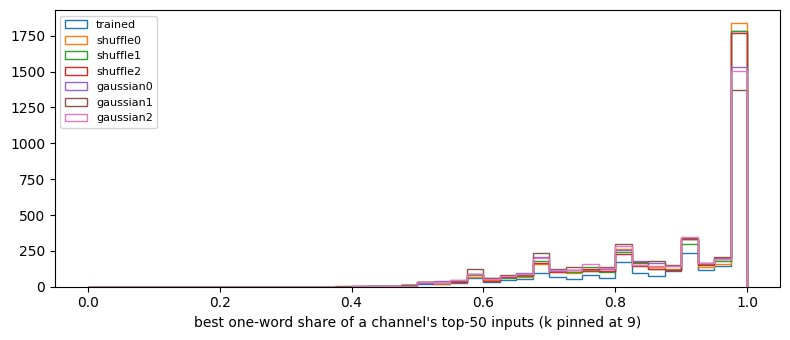


P29, second clause: nulls with median 0: none; below 0.10: none  (predicted none)

P28 rerun on nulls that respond to their input: ['shuffle0', 'shuffle1', 'shuffle2', 'gaussian0', 'gaussian1', 'gaussian2']
  median gap +0.040 (vs shuffle0, shuffle1, shuffle2); beats every scored null at every cutoff: False; a null matches trained at 0.6: True  ->  P28 REFUTED


In [11]:
md_t = motifs.enumerate_block0(hm, k=K)
share = {'trained': controls.best_word_share(md_t, live=controls.live_channels(md_t))}
for mode, sd in NULLS:
    with nullmodel.random_weights(hm, 0, mode=mode, seed=sd):
        md_n = motifs.enumerate_block0(hm, k=K)
    assert md_n.k == K
    share[f'{mode}{sd}'] = controls.best_word_share(md_n, live=controls.live_channels(md_n))
assert nullmodel.verify_restored(hm, HEALTH_SEQ, REF_LOGITS)['restored'], 'block 0 not restored; stop'

sweep = {k: controls.cutoff_sweep(v) for k, v in share.items()}
B0 = {k: {'n_live': int(len(v)), 'median': float(np.median(v)), 'q90': float(np.quantile(v, .9)),
          'sweep': sweep[k], 'responds': RESPONDS[k]} for k, v in share.items()}
RESULTS['block0_share_pinned'] = B0
print(pd.DataFrame(B0).T.to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
for k, v in share.items():
    ax.hist(v, bins=np.linspace(0, 1, 41), histtype='step', lw=2 if k == 'trained' else 1, label=k)
ax.set_xlabel("best one-word share of a channel's top-50 inputs (k pinned at 9)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

zero = [k for k in share if k != 'trained' and B0[k]['median'] == 0]
low = [k for k in share if k != 'trained' and B0[k]['median'] < 0.10]
print(f'\nP29, second clause: nulls with median 0: {zero or "none"}; below 0.10: {low or "none"}  (predicted none)')

scored = {k: v for k, v in B0.items() if k == 'trained' or v['responds']}
print(f'\nP28 rerun on nulls that respond to their input: {[k for k in scored if k != "trained"] or "NONE"}')
if len(scored) > 1:
    shuf = [k for k in scored if k.startswith('shuffle')] or [k for k in scored if k != 'trained']
    gap = scored['trained']['median'] - float(np.mean([scored[k]['median'] for k in shuf]))
    nulls = [k for k in scored if k != 'trained']
    beats = all(scored['trained']['sweep'][c] > scored[k]['sweep'][c] for k in nulls for c in scored['trained']['sweep'])
    tie06 = any(scored[k]['sweep'][0.6] >= scored['trained']['sweep'][0.6] for k in nulls)
    verdict = 'CONFIRMED' if gap >= 0.20 and beats else 'REFUTED' if gap < 0.05 or tie06 else 'IN BETWEEN'
    print(f'  median gap {gap:+.3f} (vs {", ".join(shuf)}); beats every scored null at every cutoff: {beats}; '
          f'a null matches trained at 0.6: {tie06}  ->  P28 {verdict}')
    RESULTS['p28_rerun'] = {'verdict': verdict, 'gap': gap, 'beats_all': beats, 'tie_at_06': tie06, 'nulls': nulls}
else:
    print('  no null responds to its input: P28 stays NOT SCORABLE; see R5b.2 for the cause')
    RESULTS['p28_rerun'] = {'verdict': 'NOT SCORABLE', 'nulls': []}


## Save

Put the executed notebook in `results/round5b/marv_hyena_round5b_colab_result.ipynb`, with `results_round5b.json`
next to it.

In [12]:
with open('results_round5b.json', 'w') as fh:
    json.dump(RESULTS, fh, default=jsonable, indent=1)
print('wrote results_round5b.json', os.path.getsize('results_round5b.json'), 'bytes; keys:', list(RESULTS))
try:
    from google.colab import files
    files.download('results_round5b.json')
except Exception as e:
    print('(download skipped:', e, ')')


wrote results_round5b.json 15935 bytes; keys: ['k_trained', 'sensitivity', 'per_tensor', 'block0_share_pinned', 'p28_rerun']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>